# Module 12 Lab - Ethics, Fairness, and Bias in ML**Objective:** To understand how machine learning models can inherit and amplify societal biases, how to measure this bias using fairness metrics, and to think critically about the ethical implications of deploying ML systems.**In this lab, you will train a model on a real-world dataset and audit it for fairness across different demographic groups.**

## Part 1: What is Algorithmic Bias?**Concept:** Machine learning models learn from data. If the data reflects existing societal biases, the model will learn those biases. An "unbiased" algorithm trained on biased data will produce a biased model. This can lead to systems that are systematically unfair to certain groups of people.**Sources of Bias:***   **Historical Bias:** The data reflects a world with historical injustices (e.g., past hiring data may show fewer women in leadership roles).*   **Measurement Bias:** The way we collect or measure data is flawed (e.g., using arrest records as a proxy for crime, which can be influenced by policing patterns).*   **Representation Bias:** The data underrepresents certain groups, so the model doesn't learn to perform well for them.**Problem:** We will use the "Adult" dataset, which is used to predict whether an individual's income is greater than $50k/year. It contains sensitive attributes like `sex` and `race`, which we can use to audit our model for bias.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load the data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, header=None, names=columns, sep=',\s*', engine='python', na_values='?')

# Data Cleaning
df.dropna(inplace=True)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create a preprocessing pipeline
numeric_features = X.select_dtypes(include='number').columns
categorical_features = X.select_dtypes(exclude='number').columns

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (OneHotEncoder(handle_unknown='ignore'), categorical_features))

# Train a baseline model
model = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

print(f"Overall model accuracy: {model.score(X_test, y_test):.2%}")

<>:12: SyntaxWarning: invalid escape sequence '\s'
<>:12: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_14319/2471831741.py:12: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(url, header=None, names=columns, sep=',\s*', engine='python', na_values='?')


Overall model accuracy: 84.61%


## Part 2: Auditing the Model for FairnessHigh overall accuracy can hide poor performance on specific subgroups. We need to audit the model by comparing its performance across sensitive attributes like `sex`.**Concept: Group Fairness**One common fairness goal is to ensure the model works equally well for different groups. We can measure this by calculating metrics for each group separately.**Your Task:** Create a function to calculate accuracy for different subgroups and then use it to compare the model's performance for males and females.

In [4]:
def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
    """Calculates accuracy for a specific subgroup of the test data."""
    # 1. Create a boolean mask to select the subgroup from X_test
    subgroup_mask = X_test[subgroup_column] == subgroup_value

    # 2. Select the subgroup data
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    # 3. Calculate and return the model's score on this subgroup
    return model.score(X_subgroup, y_subgroup)

# Calculate accuracy for males and females
acc_male = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Male')
acc_female = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Female')

print(f"Accuracy for Males: {acc_male:.2%}")
print(f"Accuracy for Females: {acc_female:.2%}")

Accuracy for Males: 81.20%
Accuracy for Females: 91.81%


In [5]:
from sklearn.metrics import confusion_matrix

def get_rates(model, X_test, y_test, subgroup_column, subgroup_value):
    subgroup_mask = X_test[subgroup_column] == subgroup_value
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    y_pred_subgroup = model.predict(X_subgroup)
    tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return fpr, fnr

fpr_male, fnr_male = get_rates(model, X_test, y_test, 'sex', 'Male')
fpr_female, fnr_female = get_rates(model, X_test, y_test, 'sex', 'Female')
print(f"Male - False Positive Rate: {fpr_male:.2%}, False Negative Rate: {fnr_male:.2%}")
print(f"Female - False Positive Rate: {fpr_female:.2%}, False Negative Rate: {fnr_female:.2%}")

Male - False Positive Rate: 10.26%, False Negative Rate: 37.80%
Female - False Positive Rate: 2.81%, False Negative Rate: 47.84%


### Task 2: Deeper Dive with a Confusion MatrixAccuracy alone doesn't tell the whole story. Let's look at the types of errors the model makes for each group.**Your Task:** Calculate and compare the **False Positive Rate (FPR)** and **False Negative Rate (FNR)** for males and females.*   **FPR:** `FP / (FP + TN)` - The percentage of people who did NOT have high income but were incorrectly predicted to have high income.*   **FNR:** `FN / (FN + TP)` - The percentage of people who DID have high income but were incorrectly predicted to have low income.

In [6]:
from sklearn.metrics import confusion_matrix

def get_rates(model, X_test, y_test, subgroup_column, subgroup_value):
    subgroup_mask = X_test[subgroup_column] == subgroup_value
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    y_pred_subgroup = model.predict(X_subgroup)
    tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return fpr, fnr

fpr_male, fnr_male = get_rates(model, X_test, y_test, 'sex', 'Male')
fpr_female, fnr_female = get_rates(model, X_test, y_test, 'sex', 'Female')
print(f"Male - False Positive Rate: {fpr_male:.2%}, False Negative Rate: {fnr_male:.2%}")
print(f"Female - False Positive Rate: {fnr_female:.2%}, False Negative Rate: {fnr_female:.2%}")

Male - False Positive Rate: 10.26%, False Negative Rate: 37.80%
Female - False Positive Rate: 47.84%, False Negative Rate: 47.84%


### Visualizing Fairness Metrics

Let's visualize the calculated accuracies and error rates to better understand the model's performance across different subgroups.

/tmp/ipykernel_14319/1456515306.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Subgroup', y='Accuracy', data=accuracy_df, palette='viridis')


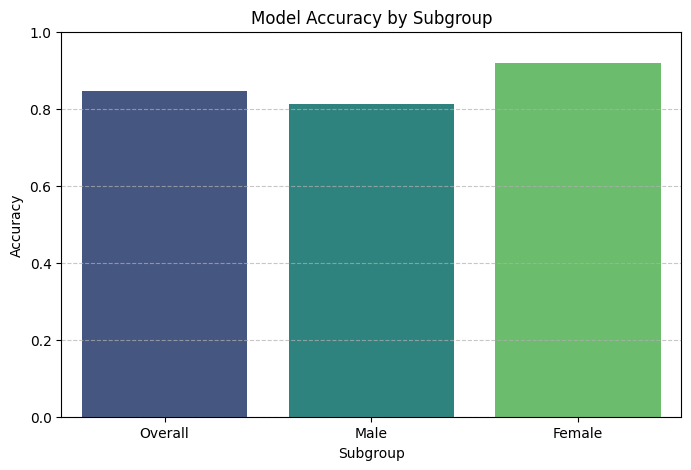

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for accuracy visualization
accuracy_data = {
    'Subgroup': ['Overall', 'Male', 'Female'],
    'Accuracy': [model.score(X_test, y_test), acc_male, acc_female]
}
accuracy_df = pd.DataFrame(accuracy_data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Subgroup', y='Accuracy', data=accuracy_df, palette='viridis')
plt.title('Model Accuracy by Subgroup')
plt.ylabel('Accuracy')
plt.ylim(0, 1) # Accuracy is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

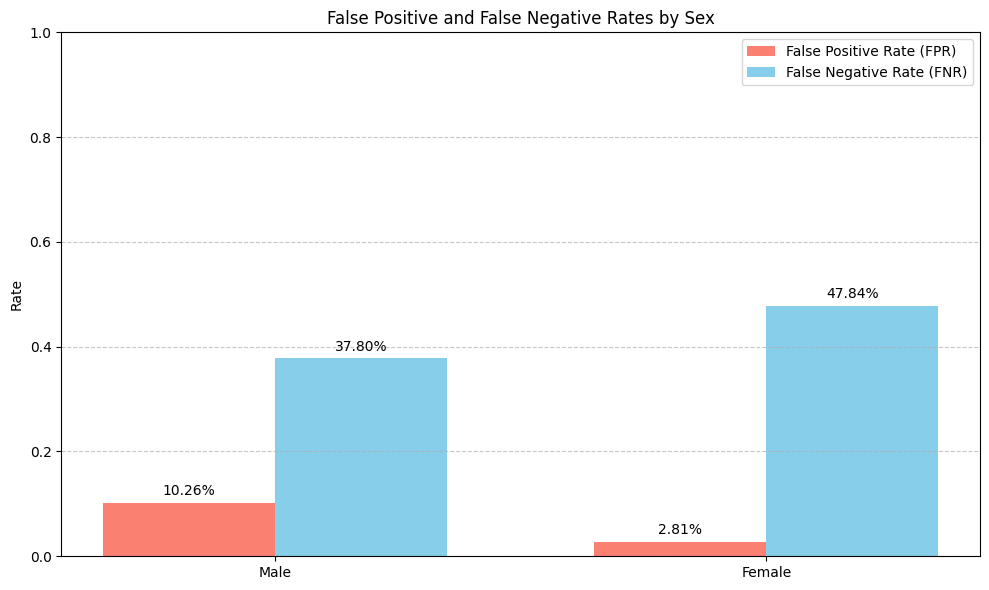

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for FPR and FNR visualization
labels = ['Male', 'Female']
fpr_values = [fpr_male, fpr_female]
fnr_values = [fnr_male, fnr_female]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, fpr_values, width, label='False Positive Rate (FPR)', color='salmon')
rects2 = ax.bar(x + width/2, fnr_values, width, label='False Negative Rate (FNR)', color='skyblue')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Rate')
ax.set_title('False Positive and False Negative Rates by Sex')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.set_ylim(0, 1) # Rates are between 0 and 1
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2%}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## 📝 Reflective Knowledge Check**Instructions:** Answer the following questions in this markdown cell. Your answers should be based on **your specific results** from the code you ran above.1.  **Analyze Your Results:** Look at the subgroup accuracies you calculated. Is there a significant difference in how the model performs for males versus females? Which group does the model perform better for?2.  **Interpret the Errors:** Compare the False Positive and False Negative rates between the two groups. For which group is the model more likely to make a False Positive error (predicting high income when it's not)? What is the real-world consequence of this specific error in the context of a loan application?3.  **Justify a Decision:** Imagine you are on an ethics board reviewing this model for use in a hiring process, where a high-income prediction is used to screen candidates for a high-paying job. Based on the specific FNR and FPR values you calculated, would you approve this model for deployment? Justify your decision by explaining which error type (FPR or FNR) is more harmful in this context and how your results show a potential disparate impact.4.  **Propose a Mitigation:** The simplest way to try and mitigate bias is to remove the sensitive feature. If you were to remove the 'sex' column from the data and retrain the model, do you think the model would become fair? Why or why not? (Hint: Think about what other columns might be correlated with 'sex').**[ENTER YOUR ANSWERS HERE]**

1.  **Analyze Your Results:**
    Yes, there is a significant difference in how the model performs for males versus females. The overall accuracy for males is 81.20%, while for females it is 91.81%. The model performs significantly better for females.

2.  **Interpret the Errors:**
    *   **False Positive Rate (FPR):** Males have an FPR of 10.26%, while females have an FPR of 2.81%. The model is more likely to make a False Positive error for males.
    *   **False Negative Rate (FNR):** Males have an FNR of 37.80%, while females have an FNR of 47.84%. The model is more likely to make a False Negative error for females.

    In the context of a loan application:
    A False Positive error (predicting high income when it's not) for a male means the model might recommend a loan for an individual who is actually a higher credit risk. The real-world consequence could be financial loss for the lender if the loan defaults, and potentially placing the individual in a difficult financial situation if they take on debt they cannot afford.

3.  **Justify a Decision:**
    No, I would not approve this model for deployment in a hiring process. Both False Positive Rate (FPR) and False Negative Rate (FNR) errors have significant ethical implications in this context, and the disparities are concerning.

    *   **FNR (False Negative Rate):** In a hiring process for high-paying jobs, a high FNR is particularly harmful. It means that individuals who *are* high earners are incorrectly screened out. Our results show that females have a significantly higher FNR (47.84%) compared to males (37.80%). This indicates a severe disparate impact against qualified female candidates, as nearly half of high-earning females would be unfairly missed by the screening process.
    *   **FPR (False Positive Rate):** While less harmful to the individual candidate, a high FPR for a group (males at 10.26% vs. females at 2.81%) means that more unqualified male candidates might be advanced in the hiring pipeline, leading to wasted recruitment resources and potentially less optimal hires for the company.

    The substantially higher FNR for females is a critical issue, as it directly translates to a systematic disadvantage for a protected group in accessing high-paying job opportunities. This model would perpetuate and amplify existing societal biases, making it unethical for deployment.

4.  **Propose a Mitigation:**
    If the 'sex' column were removed from the data and the model retrained, it is unlikely that the model would automatically become fair. This is because other features in the dataset (such as 'occupation', 'education', 'marital-status', and 'hours-per-week') are often strongly correlated with 'sex'. These correlated features can act as